<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/03_Quantum_Complexity_kappa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf Qaos
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Qaos.git

# Move into the repo
%cd Qaos

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gqs.states import Initial_state
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance
from gqs.dynamics import Hamiltonian_QK, floquet_operator_from_H
from gqs.PlotsDynamics import plot_two_gqs_trajectory_row
from gqs.Gamma import Compare_distances_All, Gamma_calculator
from gqs.SSCI import SSCI_calculator

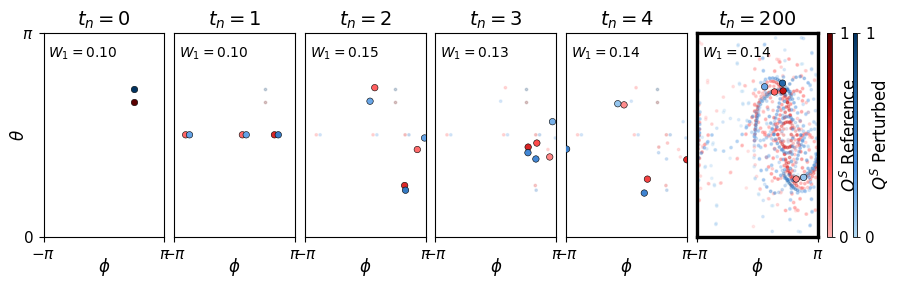

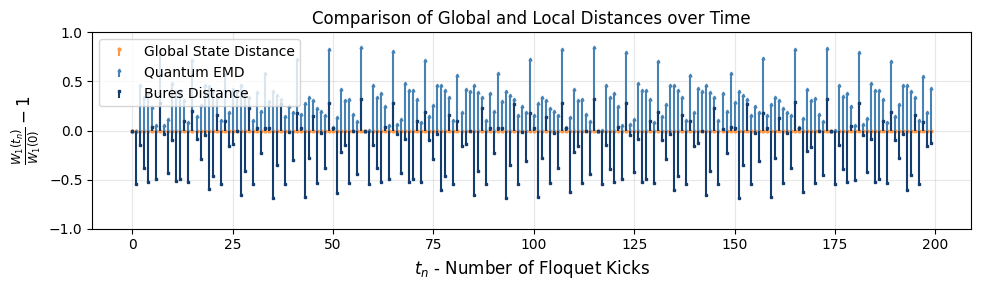

In [3]:
kappa, nqubit = 2.5, 3                                     # <--- kappa- interaction strength, nqubits - number of qubits in kicked top
H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit) # <--- Quantum Kicked Top Hamiltonian,
U_F = floquet_operator_from_H(H1,H2,tau=1.0,)              # <--- Floquet operator from QKT Hamiltonian

# Two neighboring Global States - taken to be a spin coherent state but can be changed to a more general Psi
theta, phi, eps = np.pi/2+0.5, np.pi/2, 0.2
psi_reference = Initial_state(nqubit,theta,phi)
psi_perturbed = Initial_state(nqubit, theta+eps, phi)

#Dynamics of the reduced states
_= plot_two_gqs_trajectory_row(U_F=U_F, psi_reference=psi_reference, psi_perturbed=psi_perturbed, selected_kicks=(0,1,2,3,4,200))
_=Compare_distances_All(U_F, psi_reference, psi_perturbed, N_kicks=200, show_plt=True)



# Quantifying Complexity

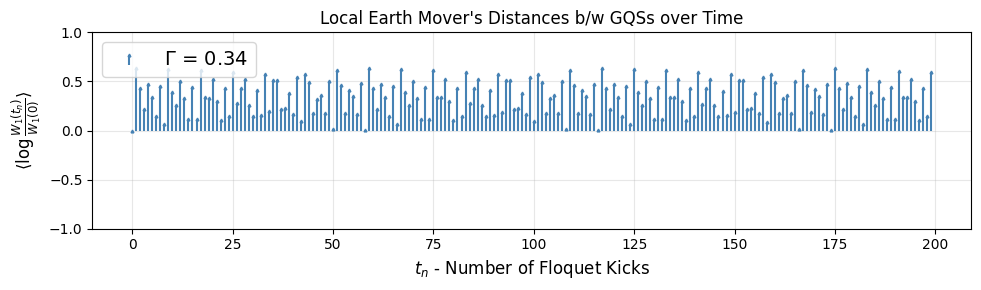

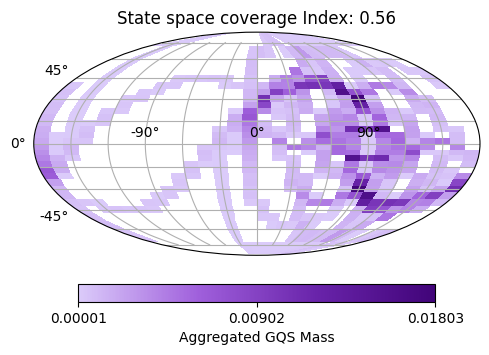

In [4]:
GammaVal,_=Gamma_calculator(U_F,theta0=theta,phi0=phi,eps=eps,N_traj=100,N_kicks=200,show_plot=True)
S1Val =SSCI_calculator(kappa=kappa,nqubit=nqubit,nkicks=5000,theta=theta,phi=phi,show_plot=True,)


# Effect of interaction Strength on Dynamics

Running for kappa = 0


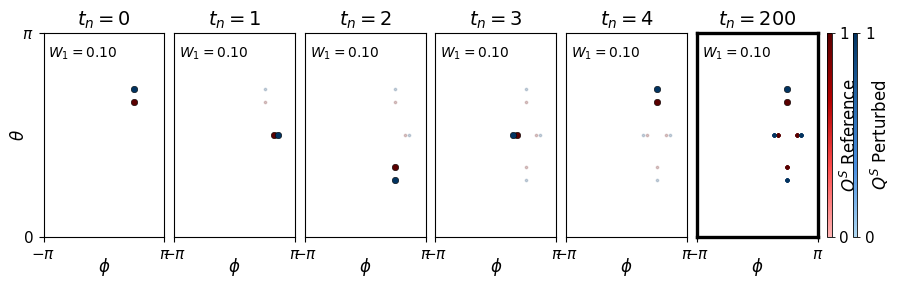

Running for kappa = 0.5


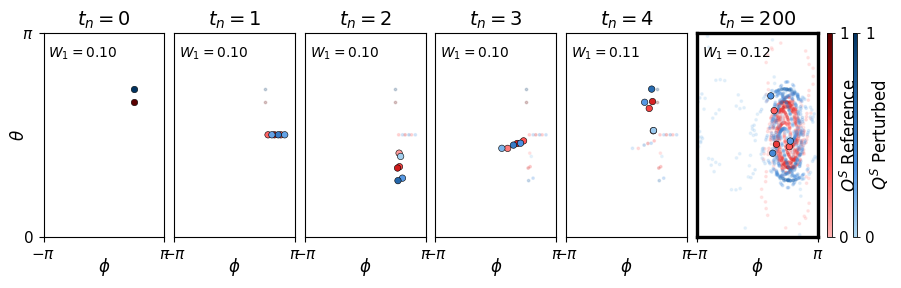

Running for kappa = 1.5


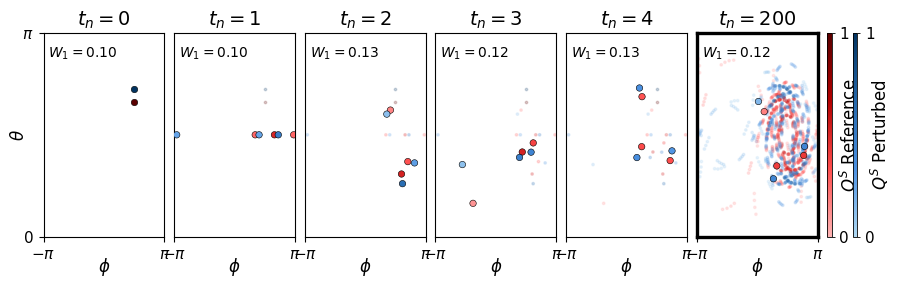

Running for kappa = 2.5


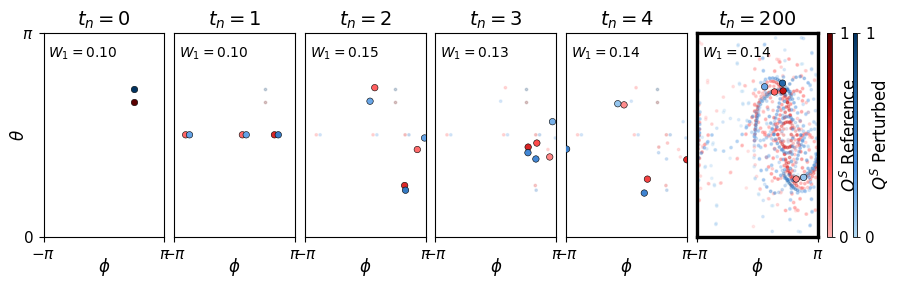

In [ ]:
kappaArr = [0,0.5,1.5,2.5]
for kappa in kappaArr:
    print(f"Running for kappa = {kappa}")
    #Dynamics of the reduced states
    H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit)
    U_F = floquet_operator_from_H(H1,H2,tau=1.0,)
    _= plot_two_gqs_trajectory_row(U_F=U_F, psi_reference=psi_reference, psi_perturbed=psi_perturbed, selected_kicks=(0,1,2,3,4,200))

# Effect of Interaction Strength on Sensitivity

Running for kappa = 0


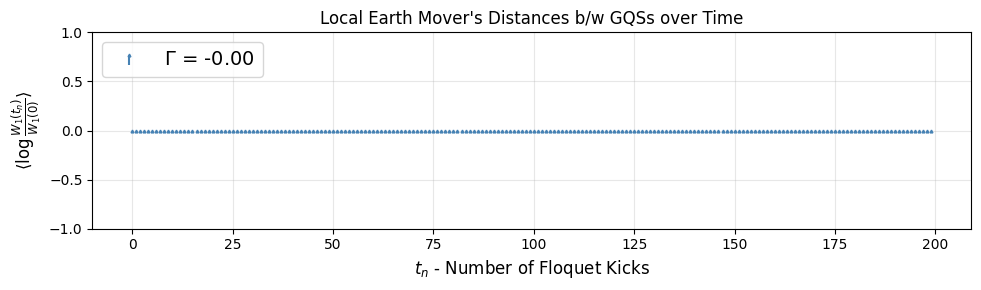

Running for kappa = 0.5


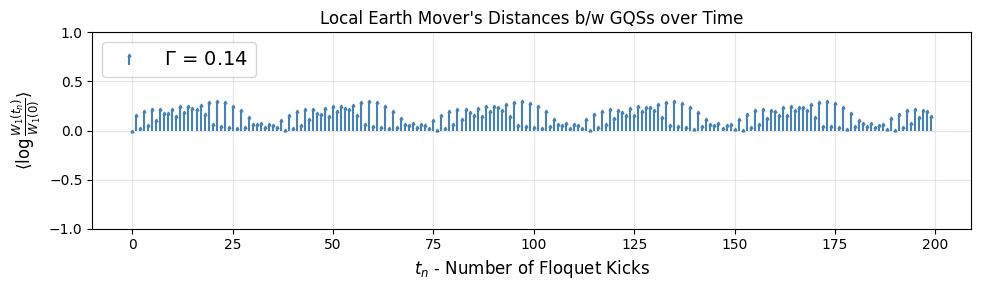

Running for kappa = 1.5


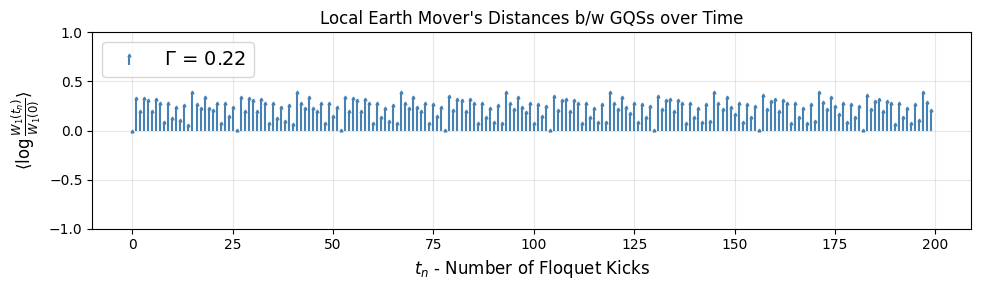

Running for kappa = 2.5


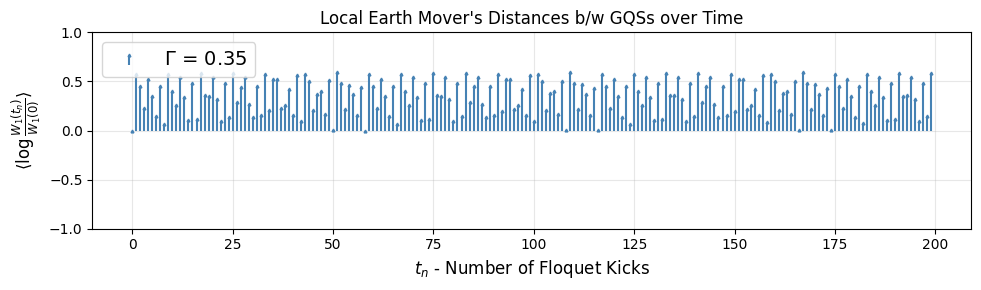

In [ ]:
for kappa in kappaArr:
    print(f"Running for kappa = {kappa}")
    H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit)
    U_F = floquet_operator_from_H(H1,H2,tau=1.0,)
    _=Gamma_calculator(U_F,theta0=theta,phi0=phi,eps=eps,N_traj=10,N_kicks=200,show_plot=True)

# Effect of Interaction Strength on Spread

Running for kappa = 0


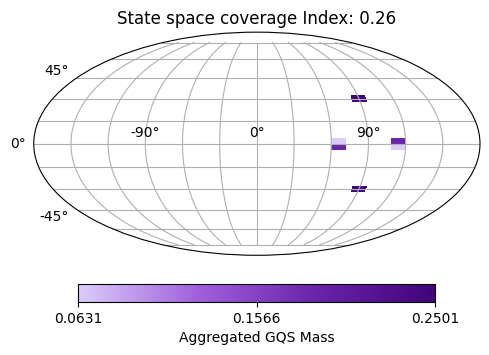

Running for kappa = 0.5


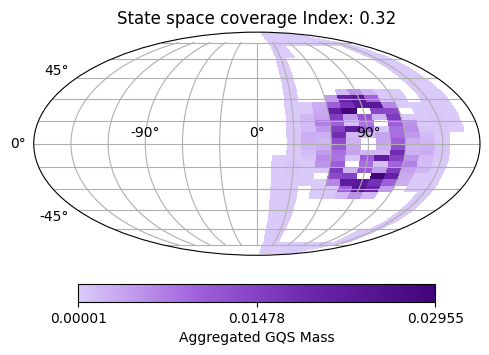

Running for kappa = 1.5


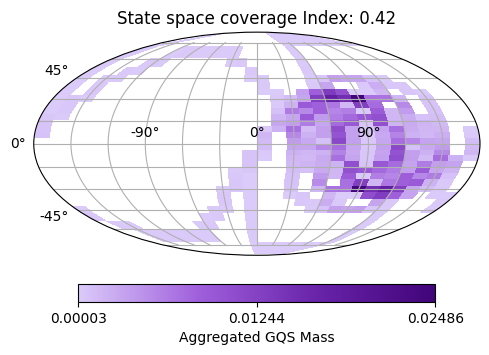

Running for kappa = 2.5


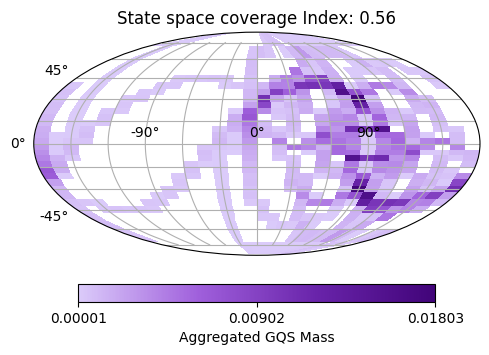

In [ ]:
kappaArr = [0,0.5,1.5,2.5]

for kappa in kappaArr:
    print(f"Running for kappa = {kappa}")
    H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit)
    U_F = floquet_operator_from_H(H1,H2,tau=1.0,)
    _=SSCI_calculator(kappa=kappa,nqubit=nqubit,nkicks=5000,theta=theta,phi=phi,show_plot=True,)


# Dependence on initial state

Running for theta = -2.2707963267948967


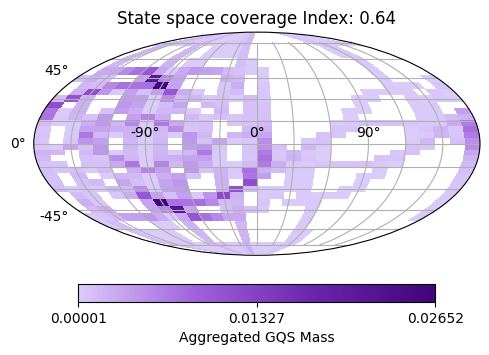

Running for theta = -1.7707963267948965


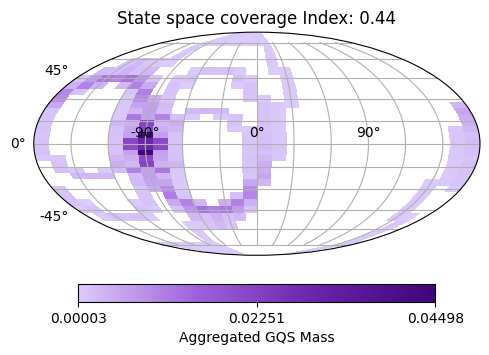

Running for theta = 0


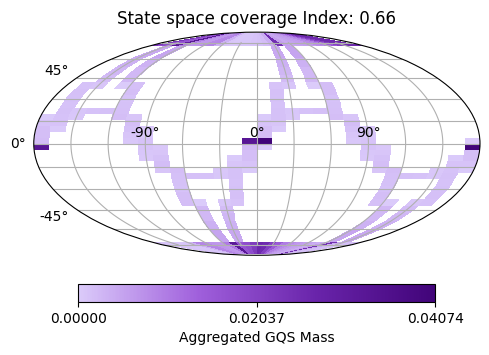

Running for theta = 1.7707963267948965


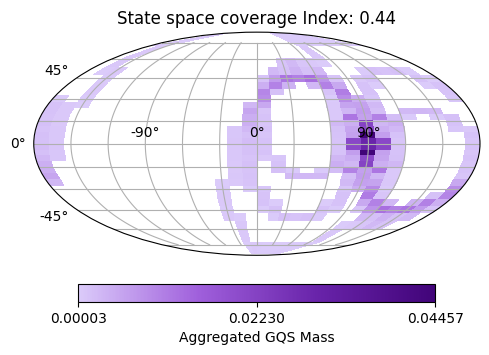

Running for theta = 2.2707963267948967


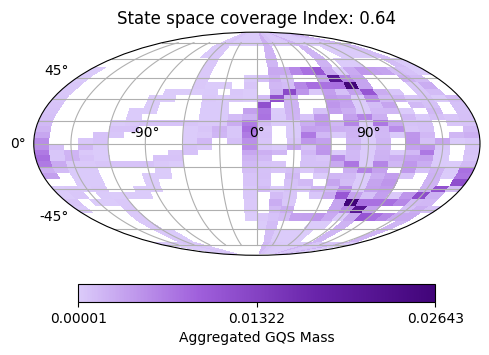

In [8]:
thetaArr = [-np.pi/2 -0.7,-np.pi/2 -0.2, 0,np.pi/2 + 0.2, np.pi/2 +0.7]
kappa = 2.5
phi = np.pi/2
for theta in thetaArr:
    print(f"Running for theta = {theta}")
    _=SSCI_calculator(kappa=kappa,nqubit=nqubit,nkicks=5000,theta=theta,phi=phi,show_plot=True,)